<a href="https://colab.research.google.com/github/sathushetty7/Dynamic-Pricing-Engine/blob/main/Dynamic_Pricing_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

In [6]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("suddharshan/retail-price-optimization")

print("Path to dataset files:", path)

100%|██████████| 24.3k/24.3k [00:00<00:00, 27.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/suddharshan/retail-price-optimization/versions/2


In [7]:
import os

dataset_path = "/root/.cache/kagglehub/datasets/suddharshan/retail-price-optimization/versions/2"

print(os.listdir(dataset_path))

['retail_price.csv']


In [8]:
file_path = "/root/.cache/kagglehub/datasets/suddharshan/retail-price-optimization/versions/2/retail_price.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully.
Shape: (676, 30)

Columns:
['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']


In [9]:
#Inspect the dataset
print(df.head())

print("\n--- Dataset Information ---")
print(df.info())

print("\n--- Missing Values ---")
print(df.isnull().sum())


  product_id product_category_name  month_year  qty  total_price  \
0       bed1        bed_bath_table  01-05-2017    1        45.95   
1       bed1        bed_bath_table  01-06-2017    3       137.85   
2       bed1        bed_bath_table  01-07-2017    6       275.70   
3       bed1        bed_bath_table  01-08-2017    4       183.80   
4       bed1        bed_bath_table  01-09-2017    2        91.90   

   freight_price  unit_price  product_name_lenght  product_description_lenght  \
0      15.100000       45.95                   39                         161   
1      12.933333       45.95                   39                         161   
2      14.840000       45.95                   39                         161   
3      14.287500       45.95                   39                         161   
4      15.100000       45.95                   39                         161   

   product_photos_qty  ...  comp_1  ps1        fp1      comp_2  ps2  \
0                   2  ...    89.

In [10]:
#EDA
print("Dataset Shape:", df.shape)

print("\n--- Descriptive Statistics ---")
print(df.describe())

print("\n--- Unique Products ---")
print(df["product_id"].nunique())

print("\n--- Product Categories ---")
print(df["product_category_name"].nunique())

print("\n--- Date Range ---")
print(df["month_year"].min(), "to", df["month_year"].max())

Dataset Shape: (676, 30)

--- Descriptive Statistics ---
              qty   total_price  freight_price  unit_price  \
count  676.000000    676.000000     676.000000  676.000000   
mean    14.495562   1422.708728      20.682270  106.496800   
std     15.443421   1700.123100      10.081817   76.182972   
min      1.000000     19.900000       0.000000   19.900000   
25%      4.000000    333.700000      14.761912   53.900000   
50%     10.000000    807.890000      17.518472   89.900000   
75%     18.000000   1887.322500      22.713558  129.990000   
max    122.000000  12095.000000      79.760000  364.000000   

       product_name_lenght  product_description_lenght  product_photos_qty  \
count           676.000000                  676.000000          676.000000   
mean             48.720414                  767.399408            1.994083   
std               9.420715                  655.205015            1.420473   
min              29.000000                  100.000000            1.0000

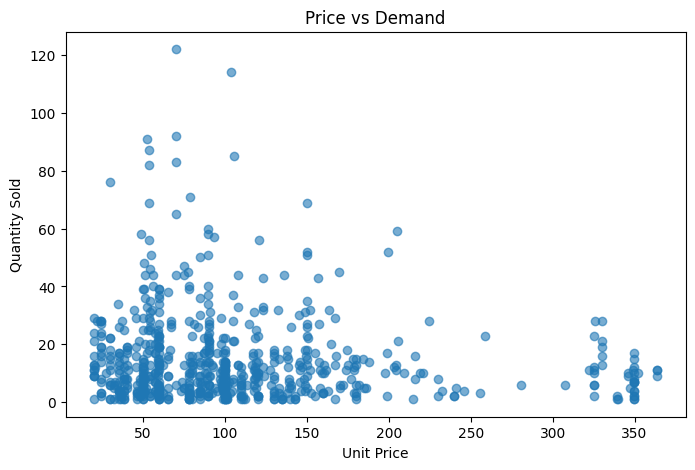

In [11]:
#Visualize Price vs Demand
plt.figure(figsize=(8, 5))

plt.scatter(
    df["unit_price"],
    df["qty"],
    alpha=0.6
)

plt.xlabel("Unit Price")
plt.ylabel("Quantity Sold")
plt.title("Price vs Demand")

plt.show()

In [12]:
correlation = df[
    ["qty", "unit_price", "customers", "comp_1", "comp_2", "comp_3", "lag_price"]
].corr()["qty"].sort_values(ascending=False)

print(correlation)

qty           1.000000
customers     0.441547
comp_2       -0.027044
comp_1       -0.033570
comp_3       -0.068522
lag_price    -0.085885
unit_price   -0.103432
Name: qty, dtype: float64


In [13]:
# Convert month_year to datetime
df["month_year"] = pd.to_datetime(
    df["month_year"],
    format="%d-%m-%Y"
)

# Select features
features = [
    "unit_price",
    "freight_price",
    "customers",
    "weekday",
    "weekend",
    "holiday",
    "month",
    "year",
    "s",
    "volume",
    "comp_1",
    "comp_2",
    "comp_3",
    "lag_price"
]

X = df[features]
y = df["qty"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (676, 14)
Target: (676,)


In [14]:
#  TRAIN / TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 540
Testing samples: 136


In [15]:
# TRAIN THE DEMAND PREDICTION MODEL

from sklearn.ensemble import RandomForestRegressor

demand_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

demand_model.fit(X_train, y_train)

print("Demand prediction model trained successfully.")

Demand prediction model trained successfully.


In [16]:
# EVALUATE THE DEMAND MODEL

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = demand_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 6.610551470588236
Root Mean Squared Error: 10.626999855044586


In [17]:
# FEATURE IMPORTANCE

importance = pd.Series(
    demand_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

s                0.335689
customers        0.167520
freight_price    0.104958
comp_2           0.100966
volume           0.075637
unit_price       0.068629
lag_price        0.039615
comp_3           0.027219
month            0.025006
comp_1           0.020614
weekday          0.013530
holiday          0.011021
year             0.005163
weekend          0.004432
dtype: float64


In [18]:
# SIMULATE DEMAND AT DIFFERENT PRICES

sample = X_test.iloc[0].copy()

current_price = sample["unit_price"]

prices = np.linspace(
    current_price * 0.7,
    current_price * 1.3,
    20
)

predicted_demand = []

for price in prices:
    scenario = sample.copy()
    scenario["unit_price"] = price

    demand = demand_model.predict(
        pd.DataFrame([scenario])
    )[0]

    predicted_demand.append(demand)

price_demand = pd.DataFrame({
    "price": prices,
    "predicted_demand": predicted_demand
})

print(price_demand)

         price  predicted_demand
0   122.103333            17.505
1   127.611754            16.680
2   133.120175            16.705
3   138.628596            16.815
4   144.137018            16.710
5   149.645439            17.045
6   155.153860            16.690
7   160.662281            16.570
8   166.170702            17.165
9   171.679123            17.120
10  177.187544            15.765
11  182.695965            15.780
12  188.204386            15.170
13  193.712807            15.170
14  199.221228            15.170
15  204.729649            15.015
16  210.238070            15.015
17  215.746491            15.070
18  221.254912            15.080
19  226.763333            15.080


In [19]:
# CALCULATE EXPECTED REVENUE

price_demand["expected_revenue"] = (
    price_demand["price"] *
    price_demand["predicted_demand"]
)

print(
    price_demand.sort_values(
        "expected_revenue",
        ascending=False
    )
)

         price  predicted_demand  expected_revenue
19  226.763333            15.080       3419.591066
18  221.254912            15.080       3336.524077
17  215.746491            15.070       3251.299622
16  210.238070            15.015       3156.724623
15  204.729649            15.015       3074.015681
14  199.221228            15.170       3022.186029
9   171.679123            17.120       2939.146582
13  193.712807            15.170       2938.623282
11  182.695965            15.780       2882.942326
12  188.204386            15.170       2855.060535
8   166.170702            17.165       2852.320095
10  177.187544            15.765       2793.361628
7   160.662281            16.570       2662.173991
6   155.153860            16.690       2589.517917
5   149.645439            17.045       2550.706500
4   144.137018            16.710       2408.529563
3   138.628596            16.815       2331.039850
2   133.120175            16.705       2223.772530
0   122.103333            17.50

In [20]:
# FIND THE OPTIMAL PRICE

best_row = price_demand.loc[
    price_demand["expected_revenue"].idxmax()
]

optimal_price = best_row["price"]
expected_demand = best_row["predicted_demand"]
expected_revenue = best_row["expected_revenue"]

print("Recommended Price:", round(optimal_price, 2))
print("Expected Demand:", round(expected_demand, 2))
print("Expected Revenue:", round(expected_revenue, 2))

Recommended Price: 226.76
Expected Demand: 15.08
Expected Revenue: 3419.59


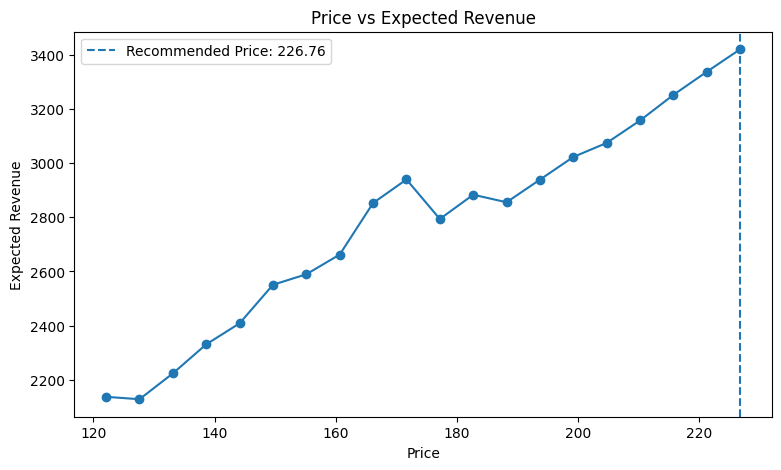

In [21]:
# VISUALIZE PRICE VS EXPECTED REVENUE

plt.figure(figsize=(9, 5))

plt.plot(
    price_demand["price"],
    price_demand["expected_revenue"],
    marker="o"
)

plt.axvline(
    optimal_price,
    linestyle="--",
    label=f"Recommended Price: {optimal_price:.2f}"
)

plt.xlabel("Price")
plt.ylabel("Expected Revenue")
plt.title("Price vs Expected Revenue")

plt.legend()
plt.show()

In [22]:
# TRAIN THE XGBOOST DEMAND MODEL

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost demand model trained successfully.")

XGBoost demand model trained successfully.


In [23]:
# EVALUATE THE XGBOOST MODEL

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("XGBoost Mean Absolute Error:", xgb_mae)
print("XGBoost Root Mean Squared Error:", xgb_rmse)

XGBoost Mean Absolute Error: 5.944085597991943
XGBoost Root Mean Squared Error: 9.335251020786412


In [24]:
# COMPARE DEMAND MODELS

print("Random Forest")
print("MAE :", mae)
print("RMSE:", rmse)

print("\nXGBoost")
print("MAE :", xgb_mae)
print("RMSE:", xgb_rmse)

if xgb_mae < mae:
    best_model = xgb_model
    print("\nSelected Model: XGBoost")
else:
    best_model = demand_model
    print("\nSelected Model: Random Forest")

Random Forest
MAE : 6.610551470588236
RMSE: 10.626999855044586

XGBoost
MAE : 5.944085597991943
RMSE: 9.335251020786412

Selected Model: XGBoost


In [25]:
# SIMULATE DEMAND USING THE BEST MODEL

sample = X_test.iloc[0].copy()

current_price = sample["unit_price"]

prices = np.linspace(
    current_price * 0.7,
    current_price * 1.3,
    50
)

predicted_demand = []

for price in prices:
    scenario = sample.copy()
    scenario["unit_price"] = price

    demand = best_model.predict(
        pd.DataFrame([scenario])
    )[0]

    predicted_demand.append(demand)

price_demand = pd.DataFrame({
    "price": prices,
    "predicted_demand": predicted_demand
})

price_demand["expected_revenue"] = (
    price_demand["price"] *
    price_demand["predicted_demand"]
)

print(price_demand.head())

        price  predicted_demand  expected_revenue
0  122.103333         14.567388       1778.726581
1  124.239252         13.232819       1644.035481
2  126.375170         13.232819       1672.299701
3  128.511088         13.282234       1706.914373
4  130.647007         13.282234       1735.284140


In [26]:
# FIND THE FINAL RECOMMENDED PRICE

best_row = price_demand.loc[
    price_demand["expected_revenue"].idxmax()
]

print("Recommended Price:", round(best_row["price"], 2))
print("Expected Demand:", round(best_row["predicted_demand"], 2))
print("Expected Revenue:", round(best_row["expected_revenue"], 2))

Recommended Price: 226.76
Expected Demand: 12.73
Expected Revenue: 2886.57


In [27]:
# CREATE THE PRICING ENGINE

def recommend_price(input_data, price_min=None, price_max=None, num_prices=50):

    scenario = input_data.copy()

    current_price = scenario["unit_price"]

    if price_min is None:
        price_min = current_price * 0.7

    if price_max is None:
        price_max = current_price * 1.3

    prices = np.linspace(
        price_min,
        price_max,
        num_prices
    )

    results = []

    for price in prices:
        test_scenario = scenario.copy()
        test_scenario["unit_price"] = price

        predicted_demand = best_model.predict(
            pd.DataFrame([test_scenario])
        )[0]

        expected_revenue = price * predicted_demand

        results.append({
            "price": price,
            "predicted_demand": predicted_demand,
            "expected_revenue": expected_revenue
        })

    results_df = pd.DataFrame(results)

    best = results_df.loc[
        results_df["expected_revenue"].idxmax()
    ]

    return best, results_df


print("Pricing engine created successfully.")

Pricing engine created successfully.


In [28]:
# TEST THE PRICING ENGINE

sample_input = X_test.iloc[0].copy()

best_price, pricing_results = recommend_price(
    sample_input
)

print("Recommended Price:", round(best_price["price"], 2))
print("Expected Demand:", round(best_price["predicted_demand"], 2))
print("Expected Revenue:", round(best_price["expected_revenue"], 2))

Recommended Price: 226.76
Expected Demand: 12.73
Expected Revenue: 2886.57


In [42]:
# SAVE THE TRAINED MODEL

import joblib

joblib.dump(best_model, "pricing_model.pkl")

print("Model saved successfully.")

# SAVE THE FEATURE LIST

joblib.dump(features, "features.pkl")

print("Feature list saved successfully.")

Model saved successfully.
Feature list saved successfully.


In [43]:
# INSTALL GRADIO

!pip install -q gradio

In [48]:
# CREATE THE FINAL CORRECTED GRADIO PRICING DASHBOARD

import gradio as gr
import pandas as pd
import numpy as np


def pricing_recommendation(
    unit_price,
    freight_price,
    customers,
    weekday,
    weekend,
    holiday,
    month,
    year,
    s,
    volume,
    comp_1,
    comp_2,
    comp_3,
    lag_price
):

    # Create input data using the exact model features
    input_data = pd.DataFrame([{
        "unit_price": float(unit_price),
        "freight_price": float(freight_price),
        "customers": int(customers),
        "weekday": int(weekday),
        "weekend": int(weekend),
        "holiday": int(holiday),
        "month": int(month),
        "year": int(year),
        "s": float(s),
        "volume": int(volume),
        "comp_1": float(comp_1),
        "comp_2": float(comp_2),
        "comp_3": float(comp_3),
        "lag_price": float(lag_price)
    }])

    # Generate candidate prices
    prices = np.linspace(
        unit_price * 0.70,
        unit_price * 1.30,
        50
    )

    results = []

    # Predict demand for every candidate price
    for price in prices:

        scenario = input_data.copy()

        # Change only the price
        scenario["unit_price"] = price

        # Predict demand
        predicted_demand = best_model.predict(
            scenario[features]
        )[0]

        # Demand cannot be negative
        predicted_demand = max(0.0, float(predicted_demand))

        # Calculate expected revenue
        expected_revenue = (
            float(price) * predicted_demand
        )

        results.append({
            "Price": float(price),
            "Predicted Demand": predicted_demand,
            "Expected Revenue": expected_revenue
        })

    # Convert results into DataFrame
    results_df = pd.DataFrame(results)

    # Find the price with maximum expected revenue
    best_index = results_df["Expected Revenue"].idxmax()

    best = results_df.loc[best_index]

    # Extract exact values used in the calculation
    best_price = float(best["Price"])
    best_demand = float(best["Predicted Demand"])
    best_revenue = float(best["Expected Revenue"])

    # Create recommendation output
    recommendation = f"""
### 💰 Recommended Price: ₹{best_price:.2f}

| Metric | Result |
|---|---:|
| **Current Price** | ₹{float(unit_price):.2f} |
| **Recommended Price** | ₹{best_price:.2f} |
| **Expected Demand** | {best_demand:.2f} units |
| **Expected Revenue** | ₹{best_revenue:.2f} |

The recommended price is the candidate price that produces the **highest predicted revenue** within the tested price range.
"""

    # Return the exact optimization table
    return recommendation, results_df.round(2)


# Create the Gradio dashboard
demo = gr.Interface(
    fn=pricing_recommendation,

    inputs=[
        gr.Number(
            value=100,
            label="Current Price (₹)"
        ),

        gr.Number(
            value=10,
            label="Freight Price"
        ),

        gr.Number(
            value=10,
            minimum=0,
            label="Customers"
        ),

        gr.Slider(
            minimum=0,
            maximum=6,
            value=2,
            step=1,
            label="Weekday"
        ),

        gr.Radio(
            choices=[0, 1],
            value=0,
            label="Weekend"
        ),

        gr.Radio(
            choices=[0, 1],
            value=0,
            label="Holiday"
        ),

        gr.Slider(
            minimum=1,
            maximum=12,
            value=6,
            step=1,
            label="Month"
        ),

        gr.Number(
            value=2018,
            label="Year"
        ),

        gr.Number(
            value=1.0,
            label="Seasonality"
        ),

        gr.Number(
            value=100,
            minimum=0,
            label="Volume"
        ),

        gr.Number(
            value=100,
            minimum=0,
            label="Competitor 1 Price (₹)"
        ),

        gr.Number(
            value=100,
            minimum=0,
            label="Competitor 2 Price (₹)"
        ),

        gr.Number(
            value=100,
            minimum=0,
            label="Competitor 3 Price (₹)"
        ),

        gr.Number(
            value=100,
            minimum=0,
            label="Previous Price (₹)"
        )
    ],

    outputs=[
        gr.Markdown(
            label="Pricing Recommendation"
        ),

        gr.Dataframe(
            headers=[
                "Price",
                "Predicted Demand",
                "Expected Revenue"
            ],
            label="Price Optimization Results",
            interactive=False
        )
    ],

    title="💰 Dynamic Pricing Engine",

    description=(
        "AI-powered pricing optimization. "
        "The system predicts demand at different prices "
        "and recommends the price that maximizes expected revenue."
    )
)


# Launch dashboard with a public link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c9c57583c3ce957e34.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
